# toy result audit

This notebook is read-only: it loads outputs produced by `main.py` from `output/fast/` and `output/full/`. It does not generate data, fit estimators, or overwrite results.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Image

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'ipy' else Path.cwd().resolve()
if not (ROOT / 'output').exists():
    ROOT = Path('..').resolve()
FAST = ROOT / 'output' / 'fast'
FULL = ROOT / 'output' / 'full'
print('Project root:', ROOT)
print('Fast exists:', FAST.exists())
print('Full exists:', FULL.exists())

Project root: D:\research\PPI\code\20260706\toyv3
Fast exists: True
Full exists: True


## Available output files

In [2]:
for mode_root in (FAST, FULL):
    print(f'\n{mode_root}:')
    if mode_root.exists():
        for path in sorted(mode_root.rglob('*')):
            if path.is_file():
                print('  ', path.relative_to(ROOT))


D:\research\PPI\code\20260706\toyv3\output\fast:
   output\fast\figure\logistic_glm_calibration.pdf
   output\fast\figure\logistic_glm_calibration.png
   output\fast\figure\logistic_glm_main_cl_950.pdf
   output\fast\figure\logistic_glm_main_cl_950.png
   output\fast\figure\lr_calibration.pdf
   output\fast\figure\lr_calibration.png
   output\fast\figure\lr_main_cl_950.pdf
   output\fast\figure\lr_main_cl_950.png
   output\fast\figure\mean_calibration.pdf
   output\fast\figure\mean_calibration.png
   output\fast\figure\mean_main_cl_950.pdf
   output\fast\figure\mean_main_cl_950.png
   output\fast\other\config_snapshot.json
   output\fast\other\diagnostics_seed0.parquet
   output\fast\other\replicate_results_seed0.parquet
   output\fast\other\run_log.txt
   output\fast\other\run_manifest.json
   output\fast\table\metrics_seed0.csv
   output\fast\table\plot_summary.csv

D:\research\PPI\code\20260706\toyv3\output\full:
   output\full\figure\logistic_glm_calibration.pdf
   output\full\fig

## Fast / full relationship

Fast and full runs use different numbers of replicates (`R=200` versus `R=2000`). Their aggregate metric tables are therefore not expected to match exactly. The relevant reproducibility check is whether the first 200 seed-0 replicate-level records are identical.


In [3]:
def read_detail(mode_root: Path, stem: str) -> pd.DataFrame | None:
    parquet = mode_root / "other" / f"{stem}.parquet"
    csv_gz = mode_root / "other" / f"{stem}.csv.gz"
    if parquet.exists():
        return pd.read_parquet(parquet)
    if csv_gz.exists():
        return pd.read_csv(csv_gz)
    return None

fast_metrics_path = FAST / "table" / "metrics_seed0.csv"
full_metrics_path = FULL / "table" / "seed0_metrics.csv"
if fast_metrics_path.exists() and full_metrics_path.exists():
    fast_metrics = pd.read_csv(fast_metrics_path)
    full_metrics = pd.read_csv(full_metrics_path)
    print("Fast R:", fast_metrics["n_replicates"].iloc[0])
    print("Full seed-0 R:", full_metrics["n_replicates"].iloc[0])

fast_rep = read_detail(FAST, "replicate_results_seed0")
full_rep = read_detail(FULL, "replicate_results_seed0")
if fast_rep is not None and full_rep is not None:
    keys = ["seed", "replicate_id", "scenario", "target", "profile", "method", "confidence_level"]
    columns = ["estimate", "standard_error", "ci_lower", "ci_upper", "ci_width", "covered", "lambda_hat"]
    candidate = full_rep[full_rep["replicate_id"] < fast_rep["replicate_id"].nunique()].copy()
    merged = fast_rep[keys + columns].merge(candidate[keys + columns], on=keys, suffixes=("_fast", "_full"), validate="one_to_one")
    numeric = ["estimate", "standard_error", "ci_lower", "ci_upper", "ci_width", "lambda_hat"]
    max_difference = max((merged[f"{name}_fast"] - merged[f"{name}_full"]).abs().max(skipna=True) for name in numeric)
    coverage_match = (merged["covered_fast"] == merged["covered_full"]).all()
    print("Matched first-fast-R interval records:", len(merged))
    print("Maximum numeric difference:", max_difference)
    print("Coverage indicators identical:", coverage_match)
else:
    print("Run full mode to compare its first fast-R seed-0 interval records against fast mode.")


Fast R: 200
Full seed-0 R: 2000
Matched first-fast-R interval records: 71400
Maximum numeric difference: 0.0
Coverage indicators identical: True


## Full robustness audit

In [4]:
robustness_path = FULL / 'table' / 'robustness_summary.csv'
if robustness_path.exists():
    robustness = pd.read_csv(robustness_path)
    display(robustness.head(20))
else:
    print('Full robustness summary is not available yet.')

,scenario,target,profile,method,confidence_level,seed0_average_ci_width,seed0_empirical_coverage,average_ci_width_median_seed1_29,average_ci_width_q25_seed1_29,average_ci_width_q75_seed1_29,average_ci_width_min_seed1_29,average_ci_width_max_seed1_29,empirical_coverage_median_seed1_29,empirical_coverage_q25_seed1_29,empirical_coverage_q75_seed1_29,empirical_coverage_min_seed1_29,empirical_coverage_max_seed1_29
0,logistic_glm,beta_0,P1,naive_ml,0.900,0.009500,0.8765,0.009498,0.009493,0.009504,0.009484,0.009510,0.8995,0.8915,0.9010,0.8825,0.9080
1,logistic_glm,beta_0,P1,naive_ml,0.950,0.011319,0.9370,0.011318,0.011312,0.011324,0.011301,0.011332,0.9490,0.9435,0.9520,0.9380,0.9600
2,logistic_glm,beta_0,P1,naive_ml,0.975,0.012945,0.9715,0.012943,0.012937,0.012950,0.012924,0.012959,0.9740,0.9705,0.9760,0.9640,0.9800
3,logistic_glm,beta_0,P1,ppi,0.900,1.333397,0.9265,1.336838,1.333699,1.338155,1.329072,1.342818,0.9205,0.9170,0.9260,0.9110,0.9340
4,logistic_glm,beta_0,P1,ppi,0.950,1.588840,0.9730,1.592941,1.589201,1.594510,1.583687,1.600066,0.9695,0.9670,0.9725,0.9630,0.9775
5,logistic_glm,beta_0,P1,ppi,0.975,1.816988,0.9900,1.821678,1.817400,1.823471,1.811095,1.829826,0.9905,0.9895,0.9925,0.9840,0.9940
6,logistic_glm,beta_0,P1,ppi_plus_plus_v1,0.900,1.309101,0.9055,1.311734,1.309305,1.313773,1.307414,1.316195,0.8990,0.8955,0.9055,0.8845,0.9155
7,logistic_glm,beta_0,P1,ppi_plus_plus_v1,0.950,1.559890,0.9550,1.563027,1.560133,1.565457,1.557880,1.568343,0.9525,0.9470,0.9545,0.9435,0.9605
8,logistic_glm,beta_0,P1,ppi_plus_plus_v1,0.975,1.783881,0.9765,1.787468,1.784159,1.790247,1.781582,1.793548,0.9770,0.9745,0.9790,0.9715,0.9840
9,logistic_glm,beta_0,P1,ppi_plus_plus_v2,0.900,1.276338,0.9085,1.280199,1.277738,1.281177,1.275365,1.284351,0.9090,0.9040,0.9115,0.8965,0.9190


## Display generated figures

logistic_glm_calibration.png


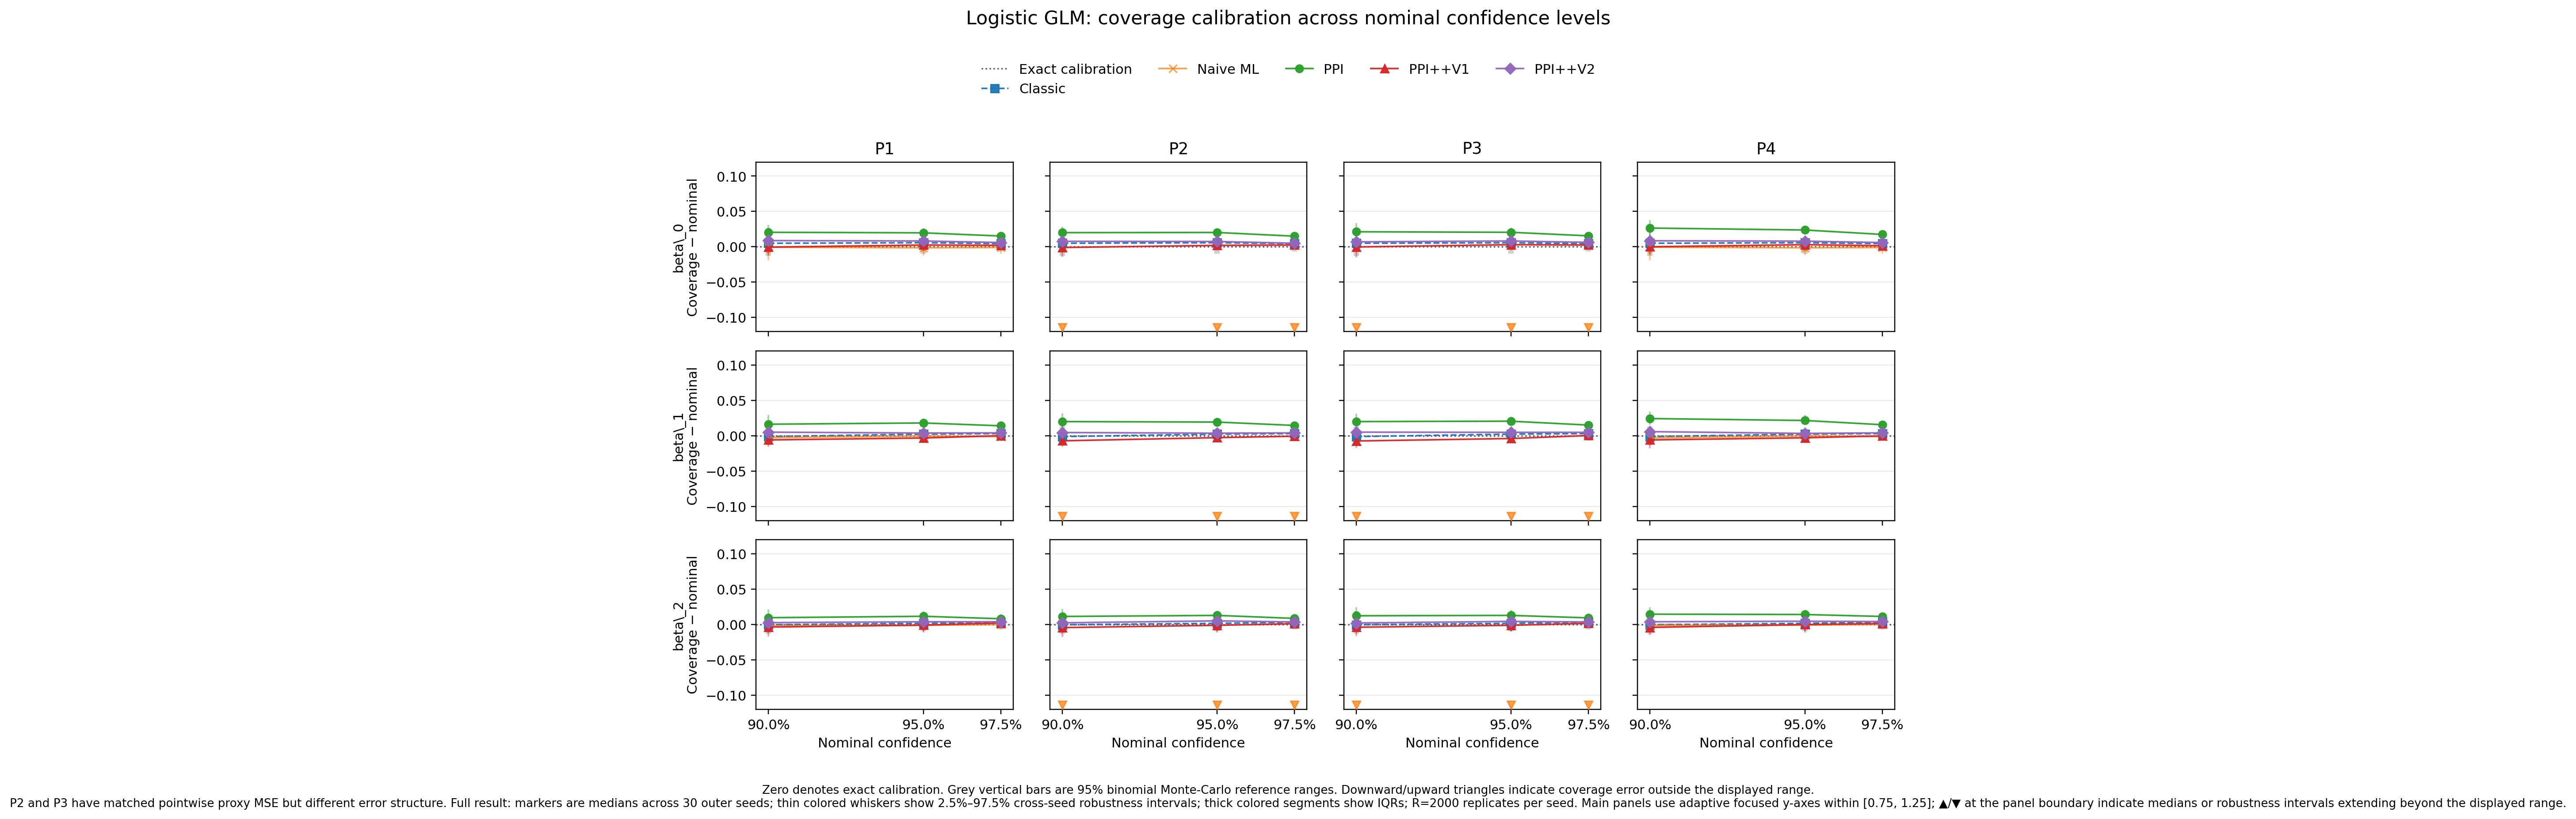

logistic_glm_main_cl_950.png


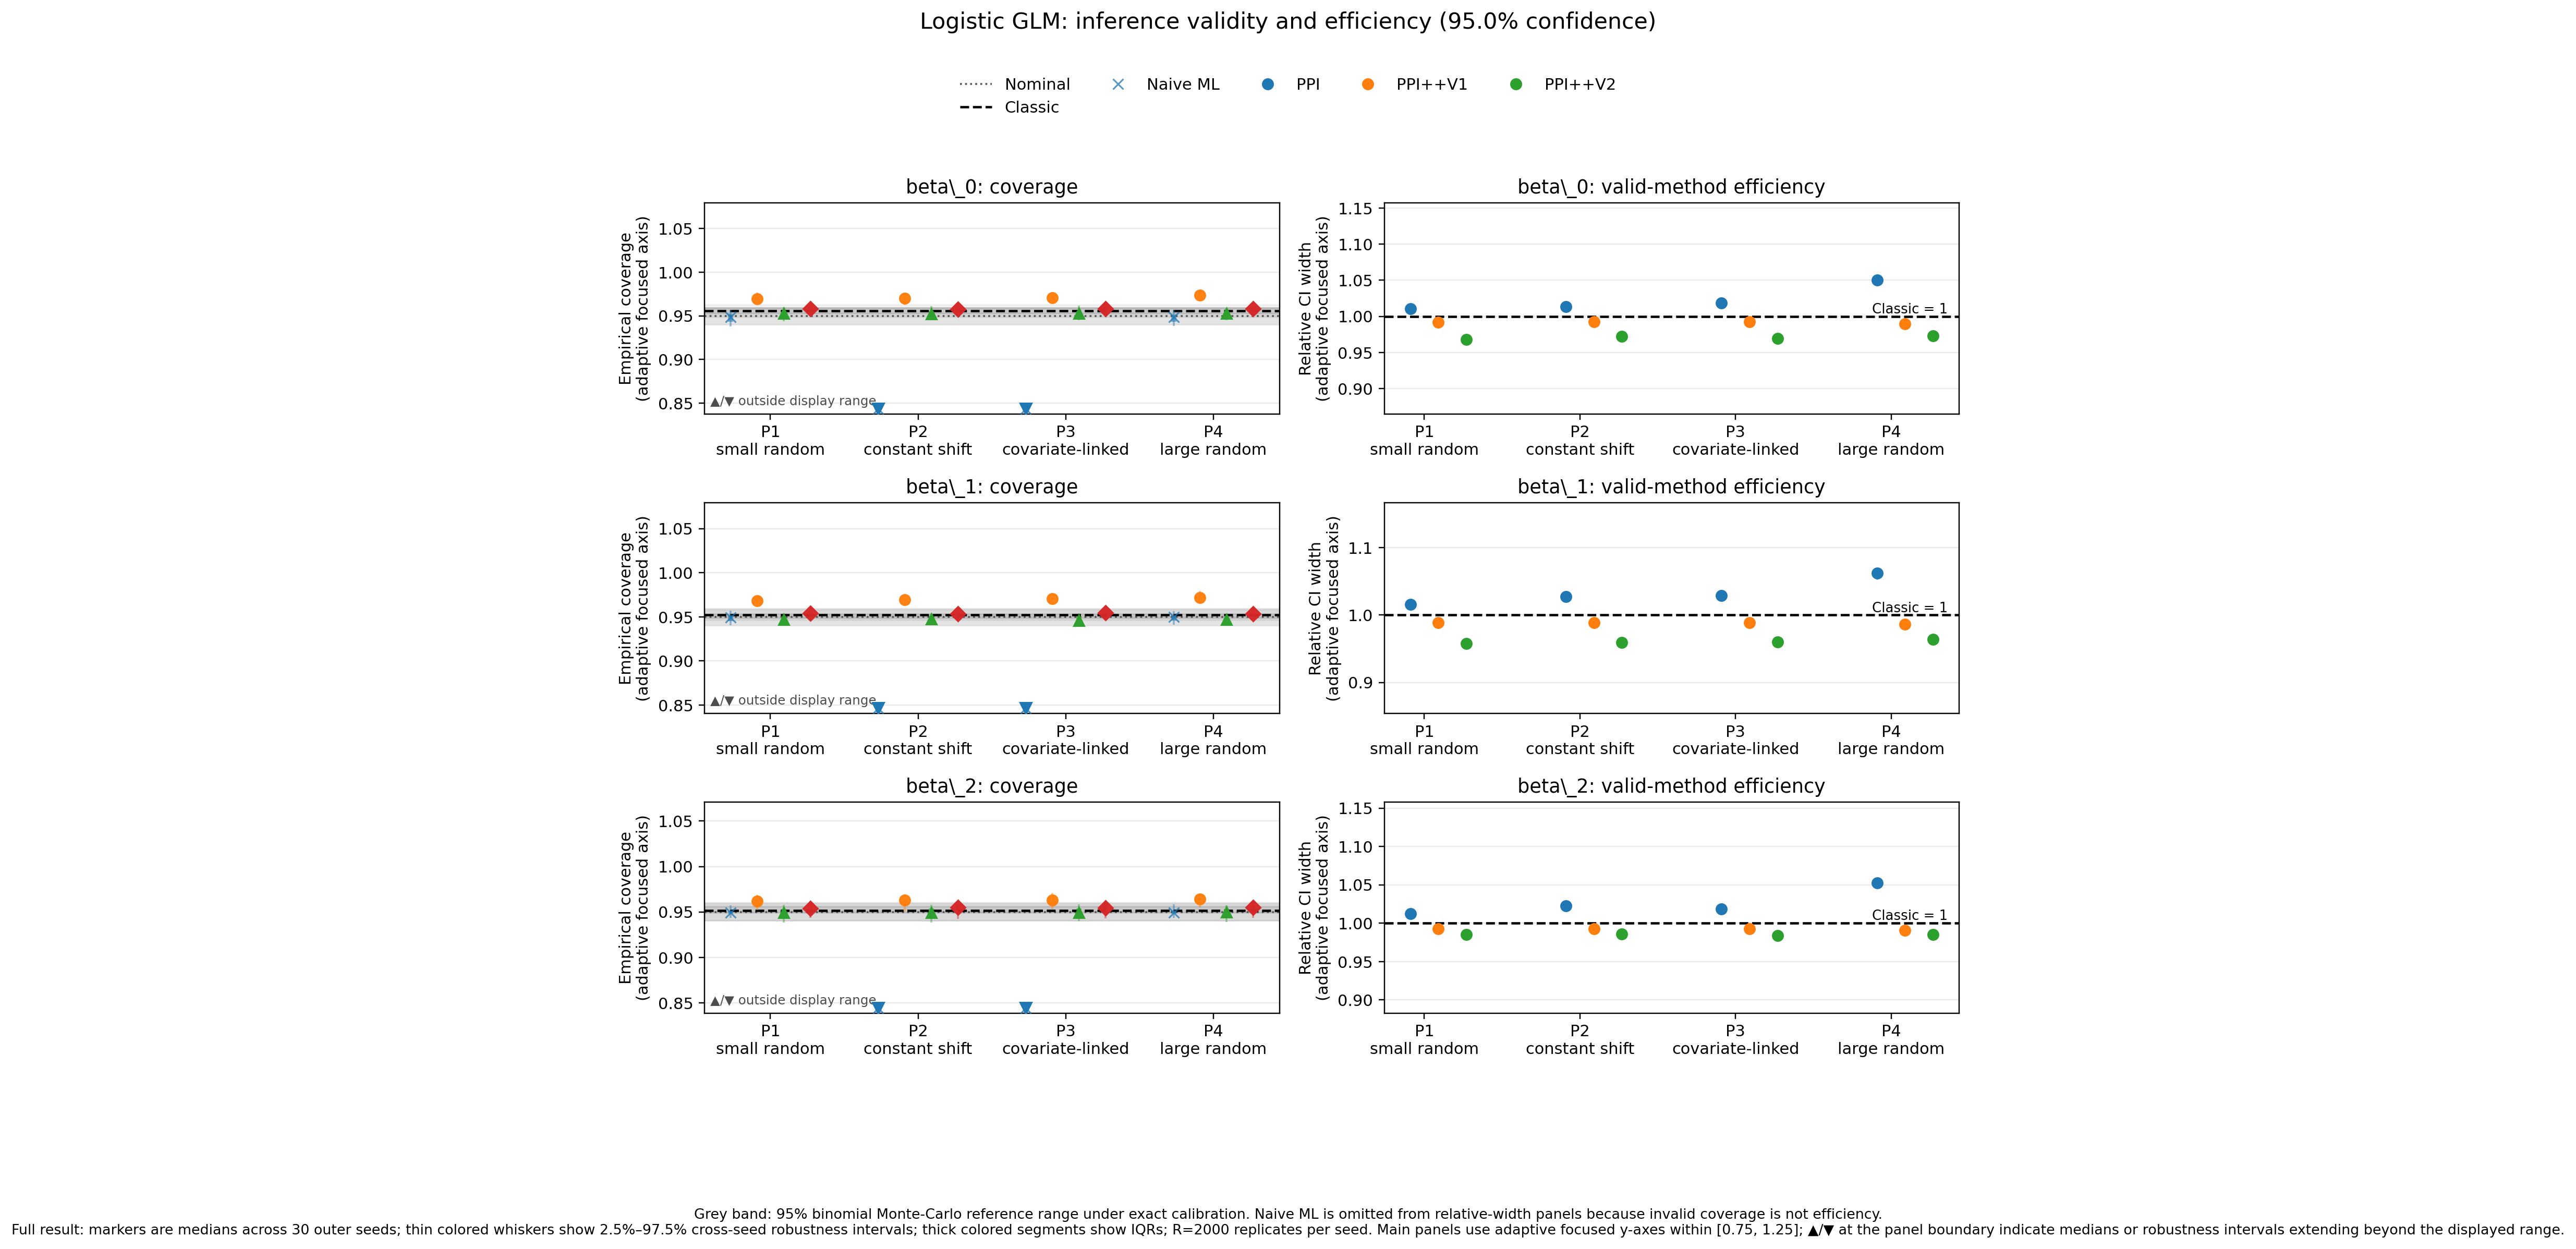

lr_calibration.png


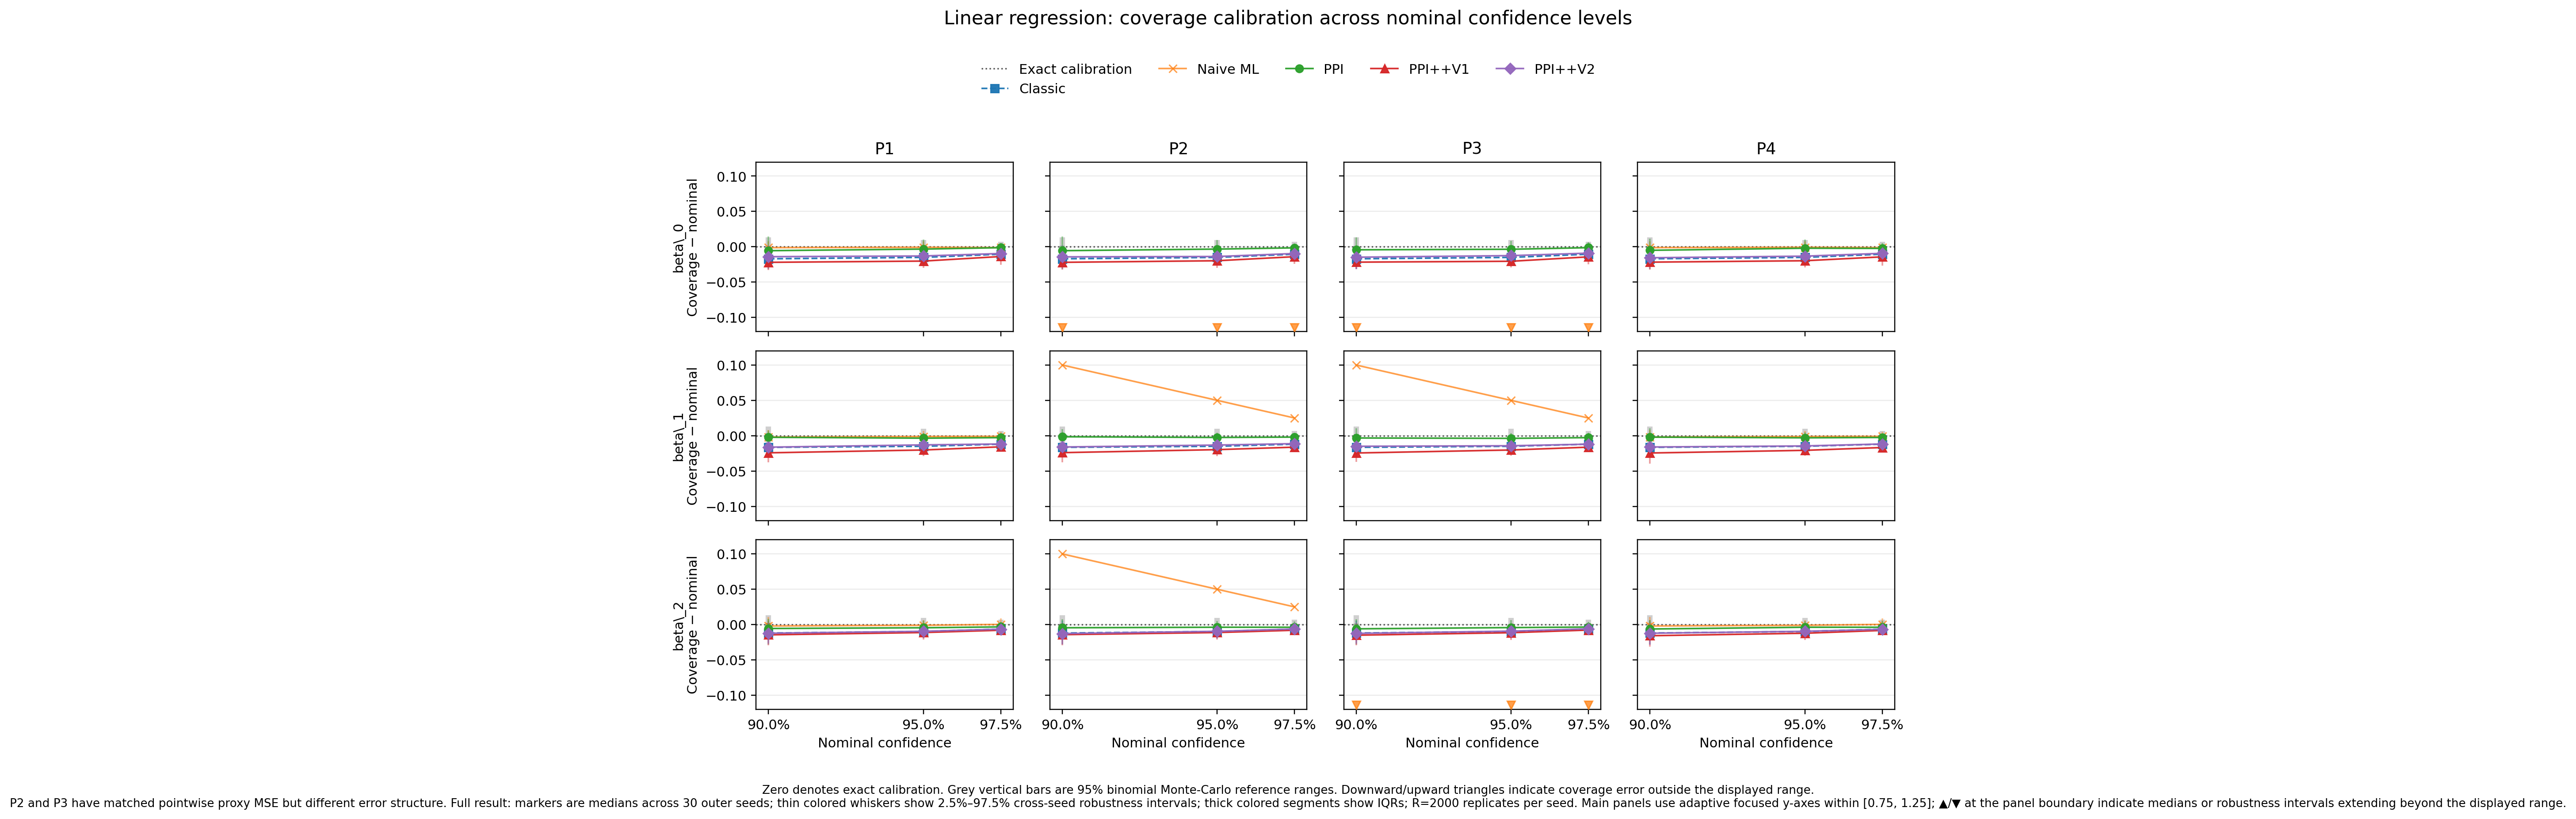

lr_main_cl_950.png


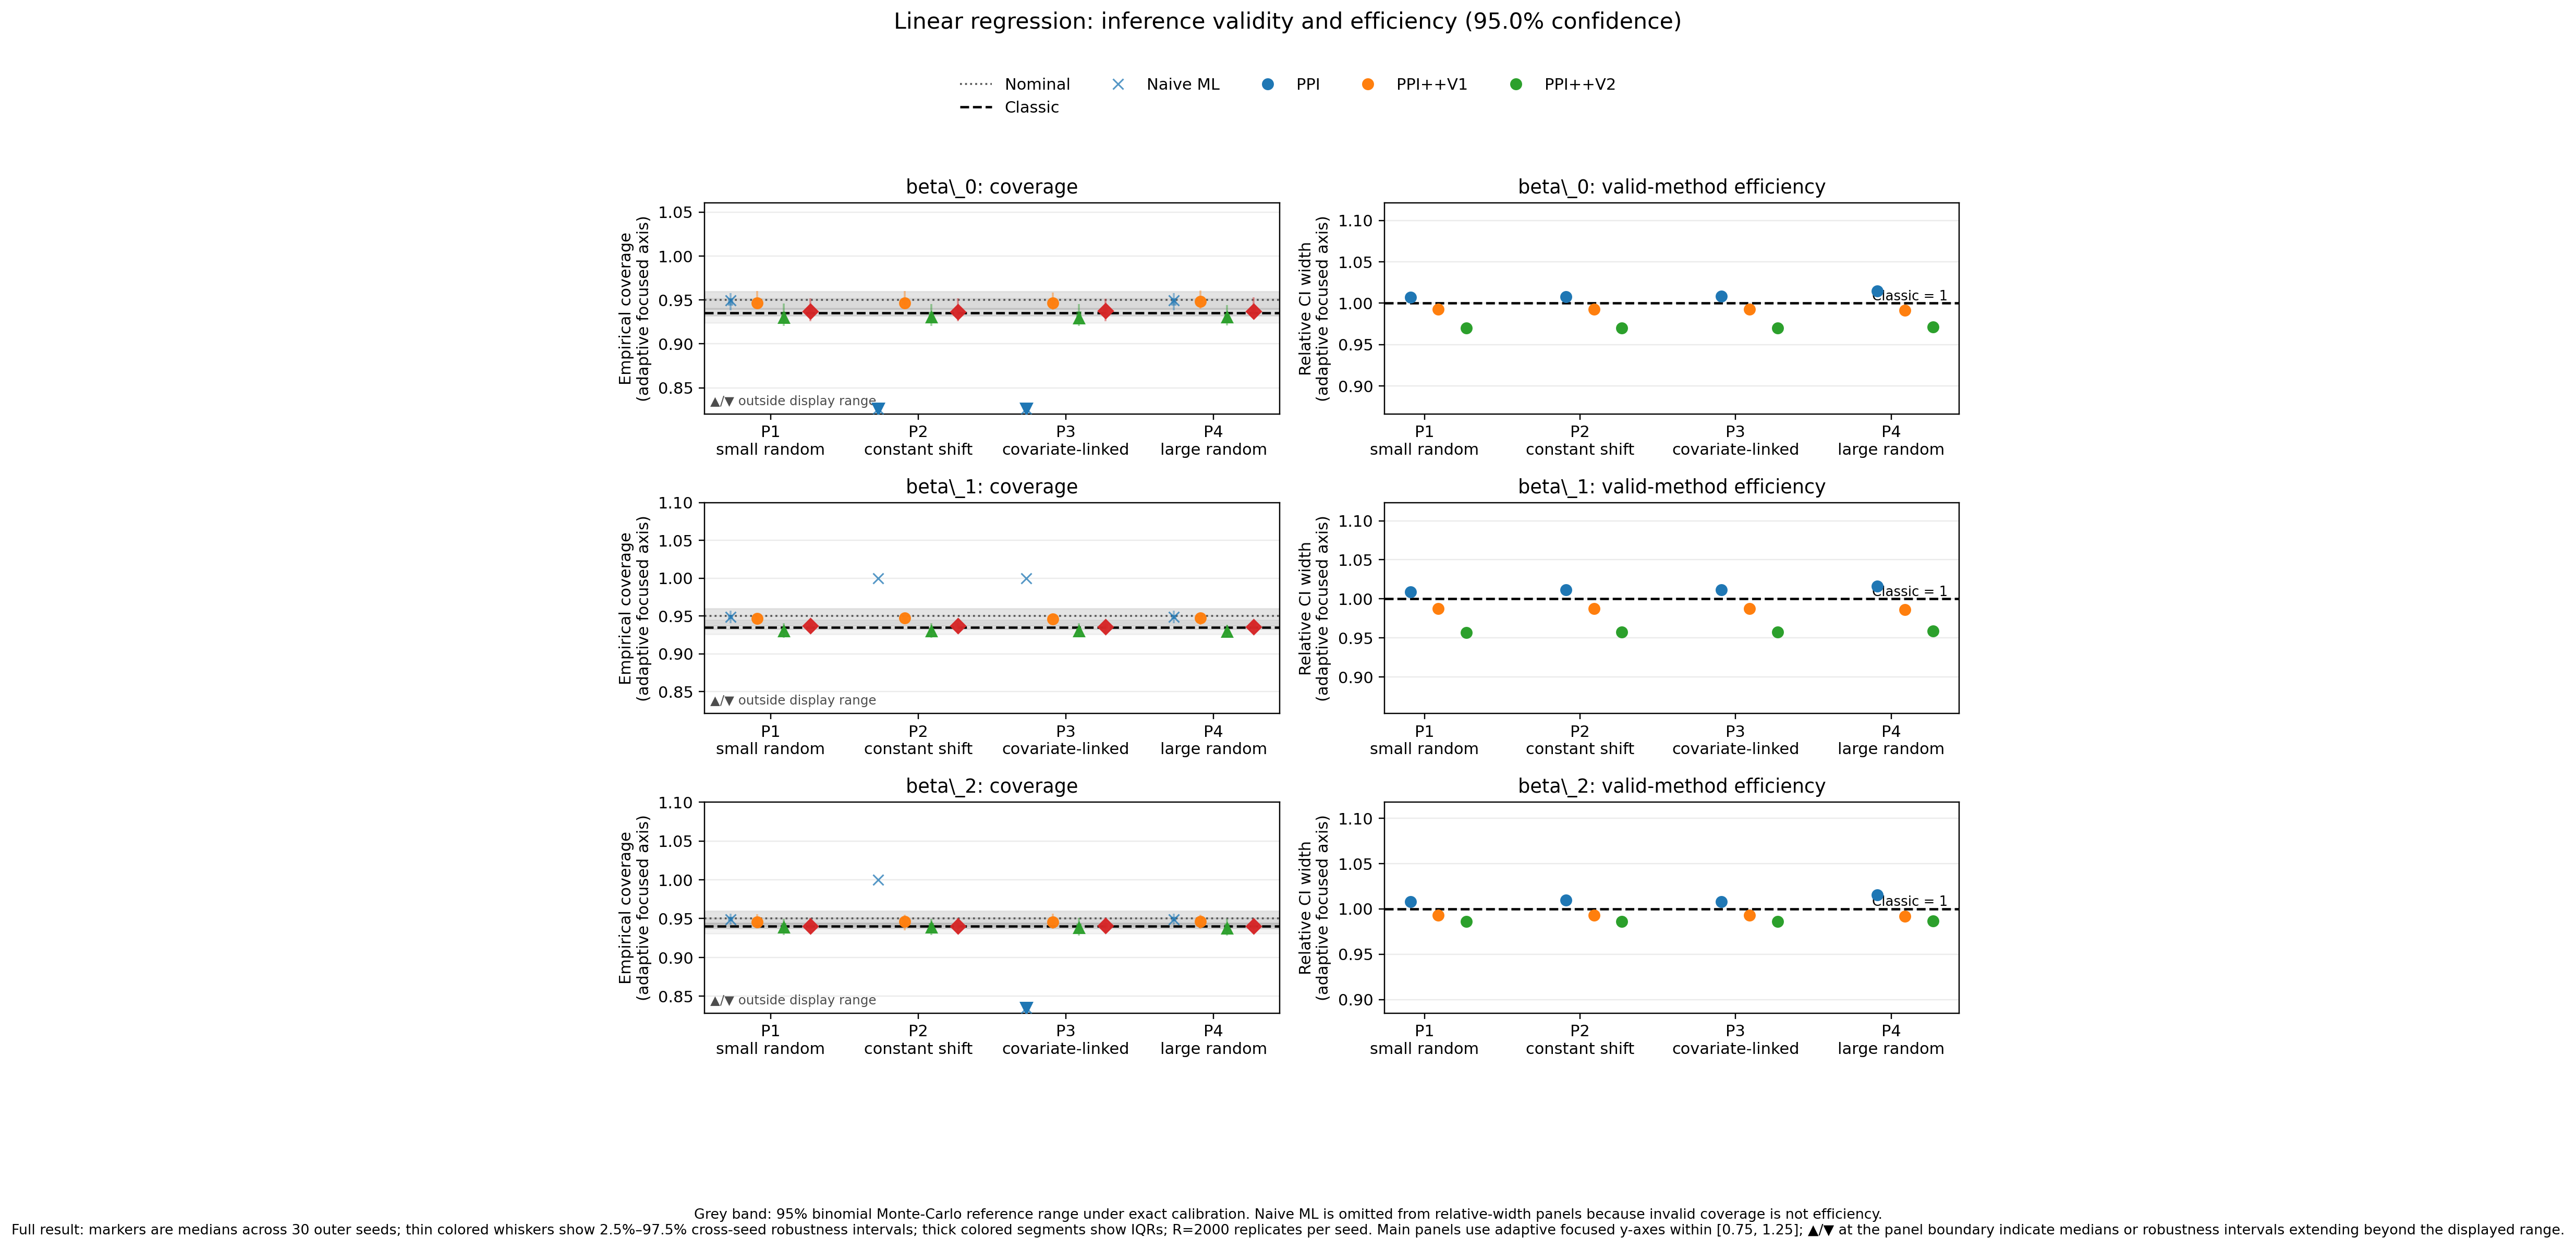

mean_calibration.png


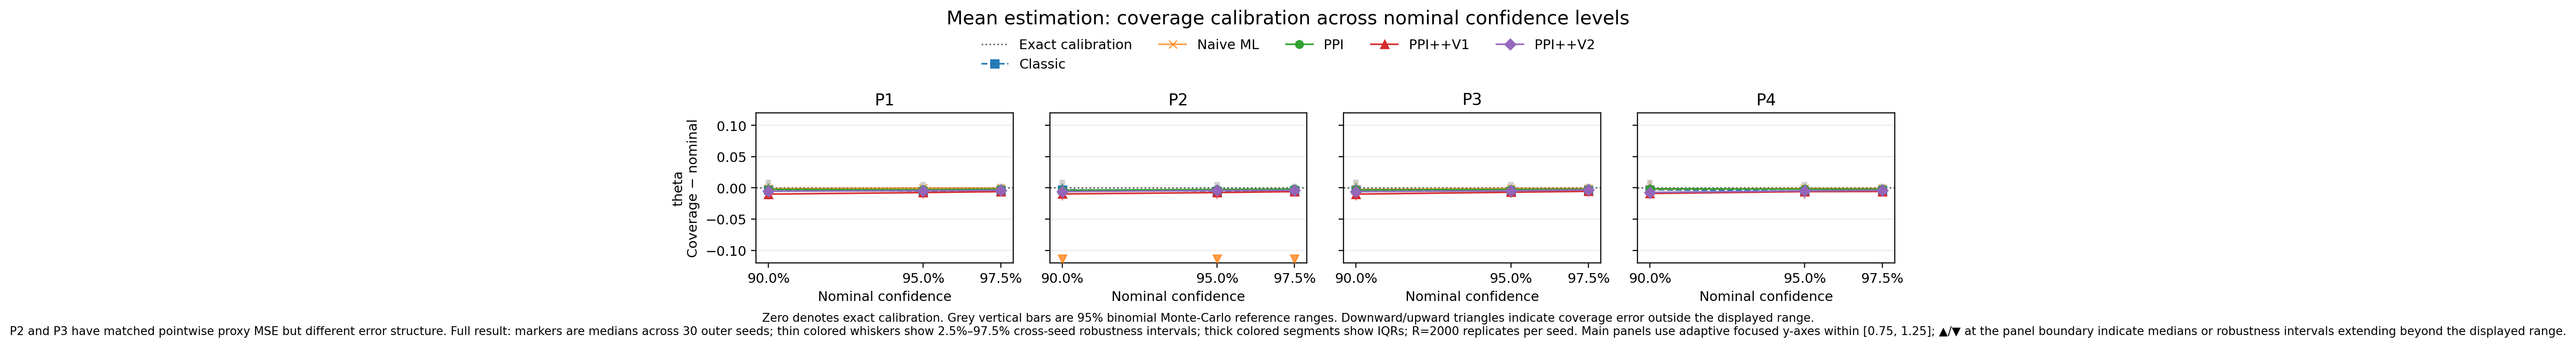

mean_main_cl_950.png


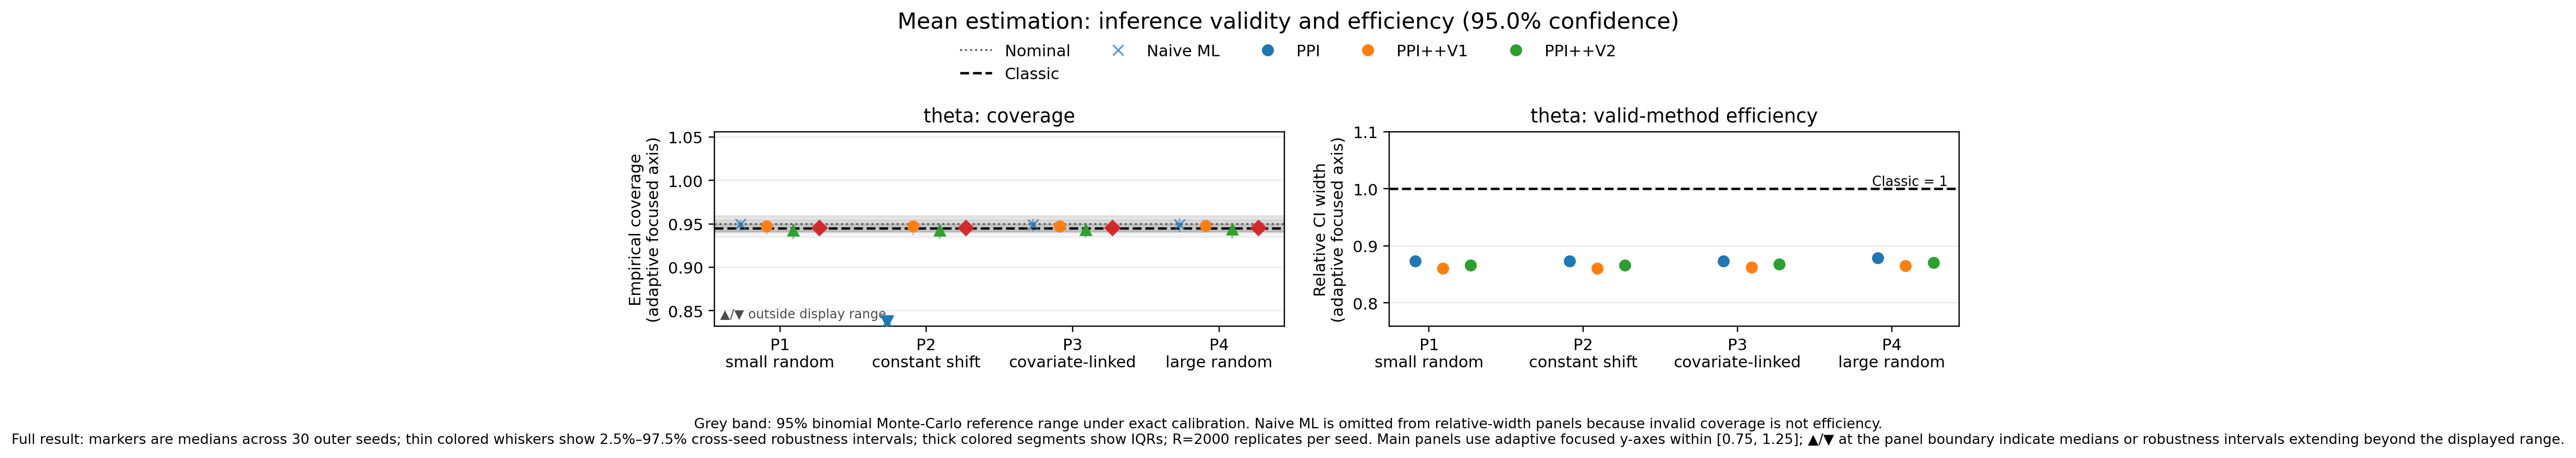

In [5]:
figure_dir = FULL / 'figure' if (FULL / 'figure').exists() else FAST / 'figure'
figures = sorted(figure_dir.glob('*.png'))
if figures:
    for figure in figures:
        print(figure.name)
        display(Image(filename=str(figure)))
else:
    print('No PNG figures found. Run main.py first.')